<a href="https://colab.research.google.com/github/Samruddhi-Waghmare/100-Days-ML/blob/main/random_forest_learning_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant = 0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.178488,1.269314,0.997151,-1.066949,0.349687,1
1,-0.582536,2.387223,2.775659,-3.930773,-0.665925,0
2,1.488969,1.840182,3.059822,-2.376921,1.327050,1
3,-1.416007,1.926103,-0.381454,-1.943792,-0.030011,0
4,-0.839923,0.000013,-4.980617,1.474081,-0.379862,0


In [4]:
def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace= True)

In [60]:
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
  return df[cols]

In [6]:
def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df, row_percent)
  return sample_features(new_df, col_percent)

In [17]:
df1 = sample_rows(df,0.1)

In [30]:
df2 = sample_rows(df,0.1)

In [31]:
df3 = sample_rows(df,0.1)

In [32]:
df1.shape

(20, 6)

In [33]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [45]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [46]:
from sklearn.tree import plot_tree

[Text(0.5, 0.8333333333333334, 'x[0] <= 0.417\ngini = 0.455\nsamples = 20\nvalue = [13, 7]'),
 Text(0.25, 0.5, 'x[4] <= 0.456\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.5, 'x[4] <= -2.295\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

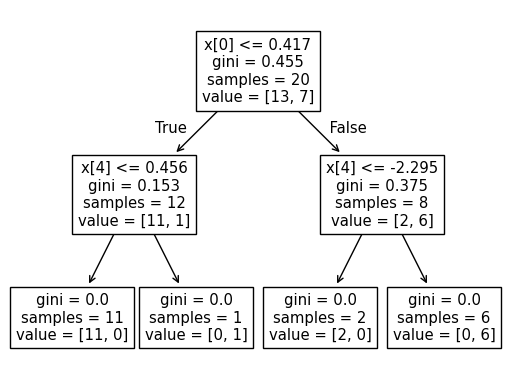

In [47]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[3] <= -1.324\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= -0.625\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

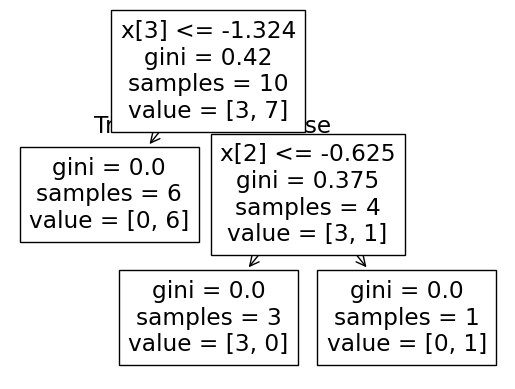

In [48]:
plot_tree(clf2)

[Text(0.4, 0.875, 'x[0] <= 0.426\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[4] <= 0.926\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 1.405\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

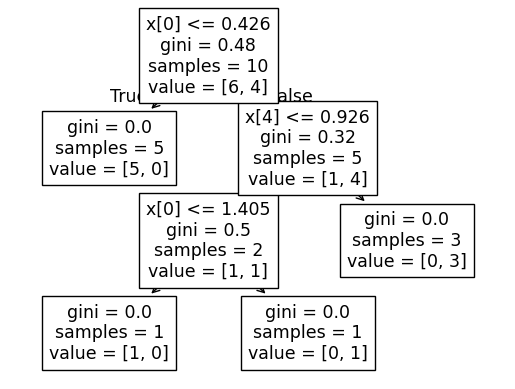

In [49]:
plot_tree(clf3)

In [51]:
clf1.predict(np.array([1.178488,1.269314,	0.997151,	-1.066949,	0.349687	]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [54]:
clf2.predict(np.array([1.178488,	1.269314,	0.997151,	-1.066949,	0.349687]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [55]:
clf3.predict(np.array([1.178488,	1.269314,	0.997151,	-1.066949,	0.349687]).reshape(1,5))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [63]:
import random
df1 = sample_features(df,0.8)

In [64]:
df2 = sample_features(df,0.8)

In [65]:
df3 = sample_features(df,0.8)

In [66]:
df3.shape

(100, 4)

In [67]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()